# Plain Analytical Avellaneda-Stoikov on DOGE

This notebook computes daily metrics for a deliberately simple analytical Avellaneda-Stoikov market maker on the DOGE replay data.

Purpose: isolate the base A-S formula without gamma tuning, drawdown penalties, CVaR constraints, PPO, or Alpha-AS parameter learning. The only data-dependent part is estimating market parameters from the training period so the model can be run on the held-out DOGE days without test-day lookahead.

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
     if (p / "procs").exists()),
    pathlib.Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from procs.gym.experiment_config import ReplayExperimentConfig
from procs.gym.data_loader import load_multi_day
from procs.gym.calibration import calibrate_from_arrays
from procs.gym.helpers.fast_rollout import fast_simulate

cfg = ReplayExperimentConfig()
cfg.ensure_artifact_dirs()
print(f"Repo root : {cfg.repo_root}")
print(f"Datasets  : {cfg.datasets_dir}")
print(f"Results   : {cfg.results_dir}")

Repo root : C:\Users\john-\Documents\Thesis_AI4T
Datasets  : C:\Users\john-\Documents\Thesis_AI4T\datasets
Results   : C:\Users\john-\Documents\Thesis_AI4T\results


## Metric Formulas

`fast_simulate` computes these metrics during the A-S rollout using the same streaming definitions used elsewhere in the project. The compact functions below are included only to make the definitions transparent on a toy path.

In [2]:
def sharpe_from_pnl(pnl_path):
    returns = np.diff(np.asarray(pnl_path, dtype=float))
    if returns.size == 0 or returns.std() <= 1e-15:
        return 0.0
    return float(returns.mean() / returns.std())


def sortino_from_pnl(pnl_path):
    returns = np.diff(np.asarray(pnl_path, dtype=float))
    downside = returns[returns < 0]
    if downside.size < 2 or downside.std() <= 1e-15:
        return 0.0
    return float(returns.mean() / downside.std())


def max_drawdown_from_pnl(pnl_path):
    pnl = np.asarray(pnl_path, dtype=float)
    running_max = np.maximum.accumulate(pnl)
    return float(np.max(running_max - pnl))


def final_pnl(pnl_path):
    return float(np.asarray(pnl_path, dtype=float)[-1])


def mean_abs_inventory(inventory_path):
    return float(np.mean(np.abs(np.asarray(inventory_path, dtype=float))))


def pnl_to_map(pnl_path, inventory_path):
    mean_abs_q = mean_abs_inventory(inventory_path)
    return float(final_pnl(pnl_path) / mean_abs_q) if mean_abs_q > 1e-15 else 0.0

In [3]:
toy_pnl = np.array([0.0, 1.0, 0.5, 1.5, 1.2, 2.0])
toy_inventory = np.array([0, 1, 1, 0, -1, 0])

pd.Series({
    "Sharpe": sharpe_from_pnl(toy_pnl),
    "Sortino": sortino_from_pnl(toy_pnl),
    "Max DD": max_drawdown_from_pnl(toy_pnl),
    "P&L-to-MAP": pnl_to_map(toy_pnl, toy_inventory),
    "Final PnL": final_pnl(toy_pnl),
    "Mean |q|": mean_abs_inventory(toy_inventory),
}, name="toy_day")

Sharpe        0.605783
Sortino       4.000000
Max DD        0.500000
P&L-to-MAP    4.000000
Final PnL     2.000000
Mean |q|      0.500000
Name: toy_day, dtype: float64

## Load DOGE Train/Test Days

The split mirrors the final notebooks: days 1-6 are used only to estimate fixed market parameters; days 7-29 are held out for reporting.

In [4]:
TRAIN_DAYS = 6
EXPECTED_TEST_DAYS = 23

daily_S, daily_dt, dates = load_multi_day(str(cfg.datasets_dir), pair=cfg.pair)
train_S = daily_S[:TRAIN_DAYS]
train_dt = daily_dt[:TRAIN_DAYS]
train_dates = dates[:TRAIN_DAYS]
test_S = daily_S[TRAIN_DAYS:]
test_dt = daily_dt[TRAIN_DAYS:]
test_dates = dates[TRAIN_DAYS:]

if len(train_S) != TRAIN_DAYS or len(test_S) != EXPECTED_TEST_DAYS:
    raise ValueError(f"Expected {TRAIN_DAYS} train and {EXPECTED_TEST_DAYS} test days, found {len(train_S)} and {len(test_S)}.")
if set(map(str, train_dates)) & set(map(str, test_dates)):
    raise ValueError("Train/test date overlap detected.")

print(f"Training days: {train_dates[0]} -> {train_dates[-1]}")
print(f"Test days    : {test_dates[0]} -> {test_dates[-1]}")

  2025-01-01:  713,815 snapshots, σ=0.000021
  2025-01-02:  766,464 snapshots, σ=0.000035
  2025-01-03:  776,383 snapshots, σ=0.000047
  2025-01-04:  778,293 snapshots, σ=0.000045
  2025-01-05:  723,494 snapshots, σ=0.000031
  2025-01-06:  766,311 snapshots, σ=0.000035
  2025-01-07:  787,093 snapshots, σ=0.000062
  2025-01-08:  821,589 snapshots, σ=0.000052
  2025-01-09:  809,421 snapshots, σ=0.000046
  2025-01-10:  789,320 snapshots, σ=0.000045
  2025-01-11:  724,826 snapshots, σ=0.000023
  2025-01-12:  719,550 snapshots, σ=0.000022
  2025-01-13:  819,981 snapshots, σ=0.000046
  2025-01-14:  775,454 snapshots, σ=0.000038
  2025-01-15:  782,299 snapshots, σ=0.000047
  2025-01-16:  788,946 snapshots, σ=0.000048
  2025-01-17:  801,259 snapshots, σ=0.000061
  2025-01-18:  829,125 snapshots, σ=0.000074
  2025-01-19:  842,892 snapshots, σ=0.000096
  2025-01-20:  857,508 snapshots, σ=0.000115
  2025-01-21:  848,107 snapshots, σ=0.000112
  2025-01-22:  812,180 snapshots, σ=0.000044
  2025-01-

## Fixed Parameters for the Plain A-S Model

This notebook intentionally does **not** tune `gamma`. We set a single plain A-S risk-aversion value and keep it fixed for all held-out days. `sigma`, `A`, and `kappa` are estimated from training days only and aggregated by median. This is not an improved or optimized baseline; it is a clean diagnostic for the raw analytical A-S formula on the DOGE data.

In [5]:
PLAIN_AS_GAMMA = 0.1

train_params = []
for S, dt, date in zip(train_S, train_dt, train_dates):
    sigma_day, A_day, kappa_day = calibrate_from_arrays(S, dt, tick_size=cfg.tick_size)
    train_params.append({"date": str(date), "sigma": sigma_day, "A": A_day, "kappa": kappa_day})

train_param_frame = pd.DataFrame(train_params).set_index("date")
sigma_plain = float(train_param_frame["sigma"].median())
A_plain = float(train_param_frame["A"].median())
kappa_plain = float(train_param_frame["kappa"].median())

print("Plain A-S parameters used for every held-out day:")
print(f"  gamma = {PLAIN_AS_GAMMA:.6f}  (fixed, not tuned)")
print(f"  sigma = {sigma_plain:.6f}  (train-only median)")
print(f"  A     = {A_plain:.4f}  (train-only median)")
print(f"  kappa = {kappa_plain:.0f}  (train-only median)")
display(train_param_frame)

Plain A-S parameters used for every held-out day:
  gamma = 0.100000  (fixed, not tuned)
  sigma = 0.000028  (train-only median)
  A     = 0.2344  (train-only median)
  kappa = 13968  (train-only median)


,sigma,A,kappa
date,,,
2025-01-01,0.000020,0.256479,39821.831357
2025-01-02,0.000027,0.279438,21646.417707
2025-01-03,0.000036,0.248103,11016.985413
2025-01-04,0.000036,0.196818,6183.921908
2025-01-05,0.000027,0.173302,13891.853983
2025-01-06,0.000028,0.220755,14043.237468


## Run Plain A-S on Held-Out Days

Each row is one held-out day. Fill randomness is averaged over `cfg.evaluation_rollouts` trajectories so the stochastic fill protocol matches the final notebooks.

In [6]:
rows = []
for i, (S, dt, date) in enumerate(zip(test_S, test_dt, test_dates)):
    stats = fast_simulate(
        midprices=S,
        dt_array=dt,
        gamma=PLAIN_AS_GAMMA,
        sigma=sigma_plain,
        kappa=kappa_plain,
        A=A_plain,
        terminal_time=float(dt.sum()),
        tick_size=cfg.tick_size,
        Q_MAX=cfg.q_max,
        num_trajectories=cfg.evaluation_rollouts,
        seed=cfg.evaluation_seed,
        use_linear_approximation=False,
    )
    rows.append({
        "Day": str(date),
        "Sharpe": float(stats["sharpe"].mean()),
        "Sortino": float(stats["sortino"].mean()),
        "Max DD": float(stats["max_drawdown"].mean()),
        "P&L-to-MAP": float(stats["pnl_to_map"].mean()),
        "Final PnL": float(stats["total_pnl"].mean()),
        "Mean |q|": float(stats["mean_abs_q"].mean()),
        "Terminal q": float(stats["terminal_q"].mean()),
        "Mean spread": float(stats["mean_spread"].mean()),
        "Near Cap Fraction": float(stats.get("near_cap_fraction", np.zeros(cfg.evaluation_rollouts)).mean()),
        "Rollouts": float(cfg.evaluation_rollouts),
    })
    print(f"[{i+1:02d}/{len(test_S)}] {date}: Sharpe={rows[-1]['Sharpe']:.4f}, MaxDD={rows[-1]['Max DD']:.6f}, PnL={rows[-1]['Final PnL']:.6f}")

df_plain_as = pd.DataFrame(rows).set_index("Day")
df_plain_as

[01/23] 2025-01-07: Sharpe=0.0165, MaxDD=0.059991, PnL=1.045815
[02/23] 2025-01-08: Sharpe=0.0194, MaxDD=0.048180, PnL=1.032680
[03/23] 2025-01-09: Sharpe=0.0222, MaxDD=0.029868, PnL=1.024305
[04/23] 2025-01-10: Sharpe=0.0231, MaxDD=0.039708, PnL=1.029309
[05/23] 2025-01-11: Sharpe=0.0417, MaxDD=0.017920, PnL=1.034623
[06/23] 2025-01-12: Sharpe=0.0456, MaxDD=0.015120, PnL=1.018828
[07/23] 2025-01-13: Sharpe=0.0230, MaxDD=0.034623, PnL=1.050613
[08/23] 2025-01-14: Sharpe=0.0277, MaxDD=0.023491, PnL=1.022086
[09/23] 2025-01-15: Sharpe=0.0224, MaxDD=0.036687, PnL=1.045956
[10/23] 2025-01-16: Sharpe=0.0221, MaxDD=0.035126, PnL=1.010093
[11/23] 2025-01-17: Sharpe=0.0182, MaxDD=0.035971, PnL=1.023541
[12/23] 2025-01-18: Sharpe=0.0159, MaxDD=0.038146, PnL=1.046559
[13/23] 2025-01-19: Sharpe=0.0090, MaxDD=0.139965, PnL=1.038231
[14/23] 2025-01-20: Sharpe=0.0099, MaxDD=0.100109, PnL=1.119375
[15/23] 2025-01-21: Sharpe=0.0099, MaxDD=0.094749, PnL=1.005819
[16/23] 2025-01-22: Sharpe=0.0197, MaxDD

,Sharpe,Sortino,Max DD,P&L-to-MAP,Final PnL,Mean |q|,Terminal q,Mean spread,Near Cap Fraction,Rollouts
Day,,,,,,,,,,
2025-01-07,0.016475,0.007644,0.059991,0.359287,1.045815,2.914091,-0.60,0.000156,0.056909,20.0
2025-01-08,0.019411,0.010017,0.048180,0.361043,1.032680,2.862700,2.40,0.000156,0.052843,20.0
2025-01-09,0.022153,0.011618,0.029868,0.354984,1.024305,2.888635,0.10,0.000156,0.054861,20.0
2025-01-10,0.023081,0.010924,0.039708,0.361778,1.029309,2.847805,-1.00,0.000156,0.053007,20.0
2025-01-11,0.041677,0.015454,0.017920,0.355175,1.034623,2.914931,0.80,0.000156,0.056459,20.0
2025-01-12,0.045650,0.016470,0.015120,0.350737,1.018828,2.906202,-1.85,0.000156,0.056541,20.0
2025-01-13,0.023044,0.012465,0.034623,0.367662,1.050613,2.860097,2.70,0.000156,0.052195,20.0
2025-01-14,0.027739,0.013011,0.023491,0.358277,1.022086,2.854875,1.00,0.000156,0.051313,20.0
2025-01-15,0.022411,0.010263,0.036687,0.360156,1.045956,2.905156,1.20,0.000156,0.057706,20.0


In [7]:
summary = pd.DataFrame({
    "Mean": df_plain_as.mean(numeric_only=True),
    "Median": df_plain_as.median(numeric_only=True),
    "Std": df_plain_as.std(numeric_only=True),
})
summary.loc[["Sharpe", "Sortino", "Max DD", "P&L-to-MAP", "Final PnL", "Mean |q|"]]

,Mean,Median,Std
Sharpe,0.023893,0.022153,0.009880
Sortino,0.010663,0.010924,0.003010
Max DD,0.045096,0.035971,0.030238
P&L-to-MAP,0.359996,0.360156,0.008528
Final PnL,1.034161,1.032680,0.022562
Mean |q|,2.875213,2.871947,0.023512


In [8]:
out_path = cfg.result_path("plain_as_test_results.csv")
df_plain_as.to_csv(out_path)
print(f"Saved plain A-S daily metrics -> {out_path}")

Saved plain A-S daily metrics -> C:\Users\john-\Documents\Thesis_AI4T\results\plain_as_test_results.csv


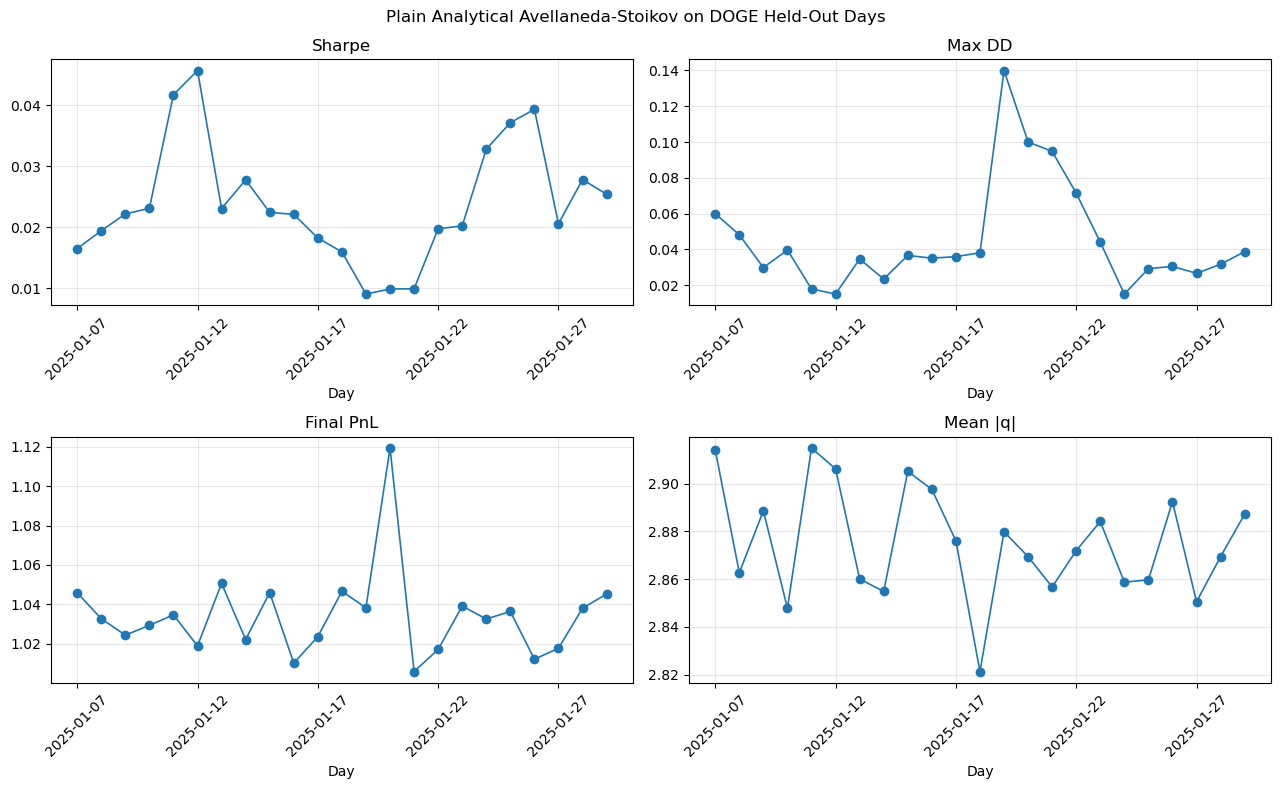

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_metrics = ["Sharpe", "Max DD", "Final PnL", "Mean |q|"]
for ax, metric in zip(axes.ravel(), plot_metrics):
    df_plain_as[metric].plot(ax=ax, marker="o", linewidth=1.2)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Plain Analytical Avellaneda-Stoikov on DOGE Held-Out Days")
plt.tight_layout()
plt.show()

## Interpretation

This is the simplest analytical A-S diagnostic in this project. It is useful for understanding what the unoptimized formula does on the DOGE replay data. It should not replace the main B0 baseline unless the thesis question is specifically about an untuned analytical benchmark. For fair model comparison, use a consistent information protocol across all methods.